In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

df = pd.read_csv("/home/sushil-singh/50_Projects/yeildsense_V1/data/yield_df.csv")

# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

print(df.head())
print(df.shape)
print(df.isnull().sum())

      Area         Item  Year  hg/ha_yield  average_rain_fall_mm_per_year  \
0  Albania        Maize  1990        36613                         1485.0   
1  Albania     Potatoes  1990        66667                         1485.0   
2  Albania  Rice, paddy  1990        23333                         1485.0   
3  Albania      Sorghum  1990        12500                         1485.0   
4  Albania     Soybeans  1990         7000                         1485.0   

   pesticides_tonnes  avg_temp  
0              121.0     16.37  
1              121.0     16.37  
2              121.0     16.37  
3              121.0     16.37  
4              121.0     16.37  
(28242, 7)
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


In [2]:
df = df.rename(columns={
    "hg/ha_yield": "yield",
    "average_rain_fall_mm_per_year": "rainfall",
    "pesticides_tonnes": "pesticides",
    "avg_temp": "temperature"
})

print(df.columns)

Index(['Area', 'Item', 'Year', 'yield', 'rainfall', 'pesticides',
       'temperature'],
      dtype='str')


In [3]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


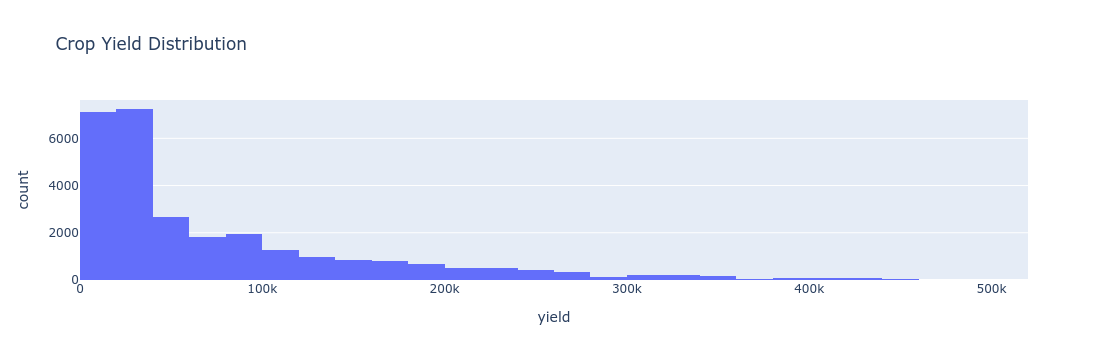

In [4]:
fig = px.histogram(
    df,
    x="yield",
    nbins=40,
    title="Crop Yield Distribution"
)

fig.show()

In [5]:
corr = df.select_dtypes("number").corr()

print(corr["yield"].sort_values(ascending=False))

yield          1.000000
Year           0.091630
pesticides     0.064085
rainfall       0.000962
temperature   -0.114777
Name: yield, dtype: float64


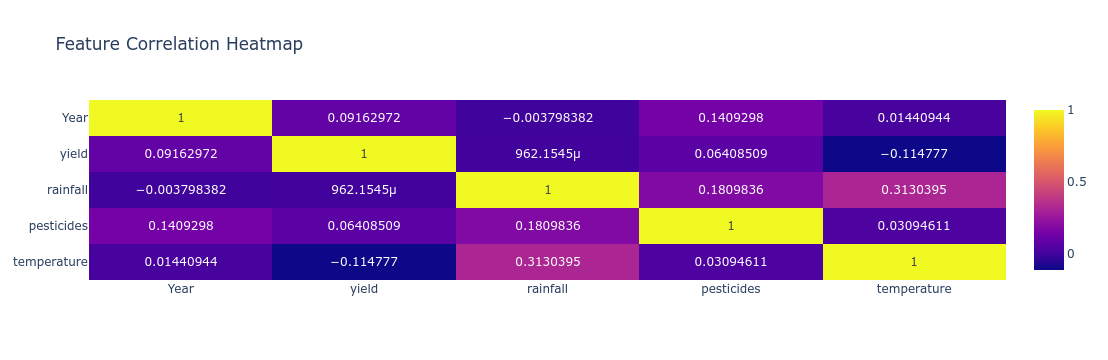

In [6]:
fig = px.imshow(
    corr,
    text_auto=True,
    aspect="auto",
    title="Feature Correlation Heatmap"
)

fig.show()

In [7]:
X = df[
    [
        "Area",
        "Item",
        "Year",
        "rainfall",
        "pesticides",
        "temperature"
    ]
]

y = df["yield"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(22593, 6)
(5649, 6)


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["Area", "Item"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R²  :", lr_r2)

Linear Regression
MAE : 31791.64792468714
RMSE: 50757.595325083974
R²  : 0.6448235468142272


In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Create Random Forest pipeline
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Evaluation
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
---------------------
MAE : 3453.3568374933616
RMSE: 9453.840219388178
R²  : 0.9876786412105895


In [13]:
from xgboost import XGBRegressor

# Create XGBoost pipeline
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test)

# Evaluation
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print("----------------")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

XGBoost Results
----------------
MAE : 10462.0751953125
RMSE: 16650.407322345
R²  : 0.9617798924446106


In [14]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        lr_r2,
        rf_r2,
        xgb_r2
    ]
})

print(results)

               Model           MAE          RMSE        R2
0  Linear Regression  31791.647925  50757.595325  0.644824
1      Random Forest   3453.356837   9453.840219  0.987679
2            XGBoost  10462.075195  16650.407322  0.961780


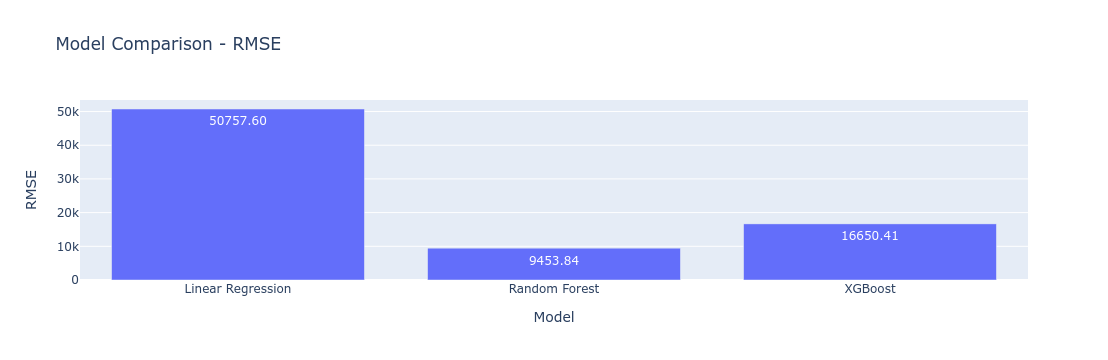

In [15]:
fig = px.bar(
    results,
    x="Model",
    y="RMSE",
    title="Model Comparison - RMSE",
    text_auto=".2f"
)

fig.show()

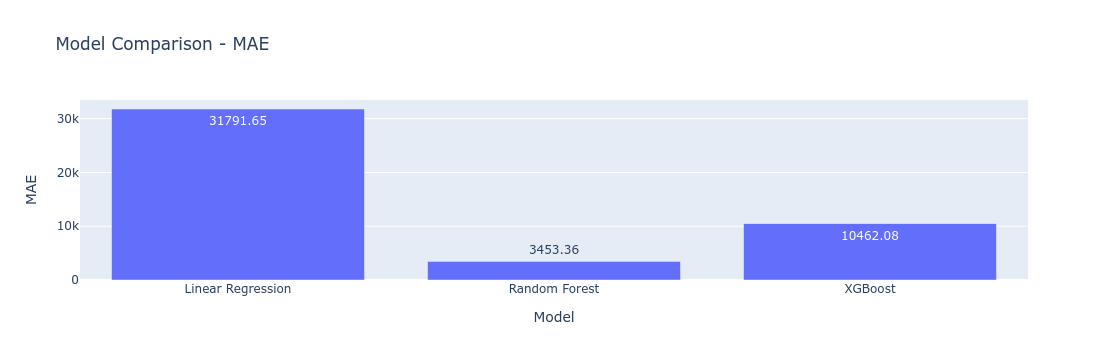

In [16]:
fig = px.bar(
    results,
    x="Model",
    y="MAE",
    title="Model Comparison - MAE",
    text_auto=".2f"
)

fig.show()

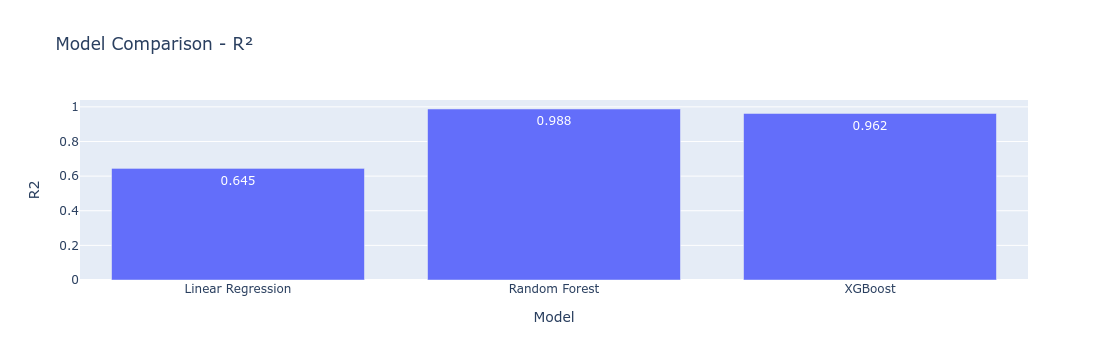

In [17]:
fig = px.bar(
    results,
    x="Model",
    y="R2",
    title="Model Comparison - R²",
    text_auto=".3f"
)

fig.show()

In [18]:
best_rmse_model = results.loc[
    results["RMSE"].idxmin()
]

print("Best model according to RMSE:")
print(best_rmse_model)

Best model according to RMSE:
Model    Random Forest
MAE        3453.356837
RMSE       9453.840219
R2            0.987679
Name: 1, dtype: object


In [19]:
best_r2_model = results.loc[
    results["R2"].idxmax()
]

print("\nBest model according to R²:")
print(best_r2_model)


Best model according to R²:
Model    Random Forest
MAE        3453.356837
RMSE       9453.840219
R2            0.987679
Name: 1, dtype: object


In [20]:
import pandas as pd
import plotly.express as px

# Get the fitted Random Forest model
rf = rf_model.named_steps["model"]

# Get the fitted encoder
encoder = rf_model.named_steps["preprocessor"].named_transformers_["cat"]

# Get encoded categorical feature names
encoded_features = encoder.get_feature_names_out(["Area", "Item"])

# Numerical feature names
numerical_features = [
    "Year",
    "rainfall",
    "pesticides",
    "temperature"
]

# Combine all feature names
feature_names = list(encoded_features) + numerical_features

# Get feature importance
importance = rf.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Show top 20
print(feature_importance.head(20))

                       Feature  Importance
104              Item_Potatoes    0.369454
101               Item_Cassava    0.102510
108        Item_Sweet potatoes    0.086242
113                 pesticides    0.070434
42                  Area_India    0.058446
112                   rainfall    0.043106
114                temperature    0.042271
111                       Year    0.032724
110                  Item_Yams    0.027481
97         Area_United Kingdom    0.017318
48                  Area_Japan    0.016230
103  Item_Plantains and others    0.015420
19                 Area_Canada    0.010708
5               Area_Australia    0.009804
62                 Area_Mexico    0.006001
69            Area_New Zealand    0.005776
68            Area_Netherlands    0.005675
36              Area_Guatemala    0.005384
26                Area_Ecuador    0.004226
90            Area_Switzerland    0.004165


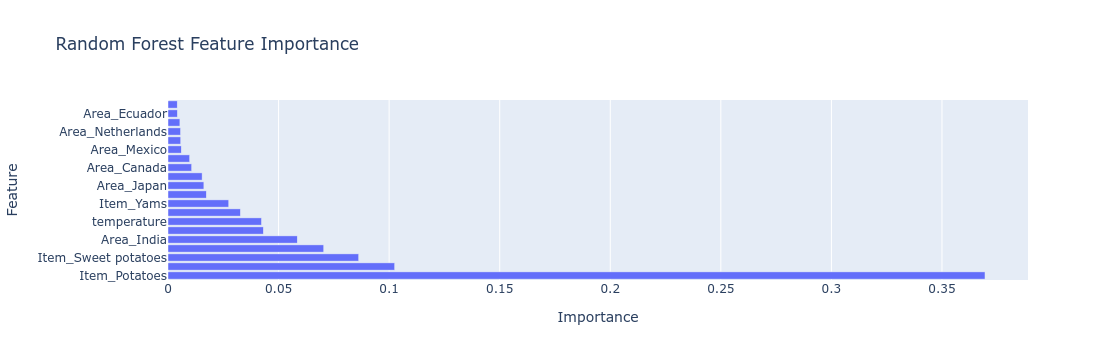

In [21]:
top_features = feature_importance.head(20)

fig = px.bar(
    top_features,
    x="Importance",
    y="Feature",
    orientation="h",
    title="Random Forest Feature Importance"
)

fig.show()

In [22]:
# ==========================================
# STEP 9: TIME-BASED TRAIN / TEST SPLIT
# ==========================================

import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------
# 1. Sort data by year
# ------------------------------------------

df = df.sort_values("Year").reset_index(drop=True)

# ------------------------------------------
# 2. Find the year that separates
#    training and testing data
# ------------------------------------------

years = sorted(df["Year"].unique())

split_index = int(len(years) * 0.8)

train_years = years[:split_index]
test_years = years[split_index:]

print("Training years:")
print(train_years)

print("\nTesting years:")
print(test_years)

# ------------------------------------------
# 3. Create train and test datasets
# ------------------------------------------

train_df = df[df["Year"].isin(train_years)].copy()
test_df = df[df["Year"].isin(test_years)].copy()

print("\nTraining shape:", train_df.shape)
print("Testing shape :", test_df.shape)

# ------------------------------------------
# 4. Separate X and y
# ------------------------------------------

features = [
    "Area",
    "Item",
    "Year",
    "rainfall",
    "pesticides",
    "temperature"
]

X_train_time = train_df[features]
y_train_time = train_df["yield"]

X_test_time = test_df[features]
y_test_time = test_df["yield"]

# ------------------------------------------
# 5. Preprocessing
# ------------------------------------------

categorical_features = ["Area", "Item"]

preprocessor_time = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

# ==========================================
# 6. LINEAR REGRESSION
# ==========================================

lr_time = Pipeline([
    ("preprocessor", preprocessor_time),
    ("model", LinearRegression())
])

lr_time.fit(X_train_time, y_train_time)

lr_time_pred = lr_time.predict(X_test_time)

lr_time_mae = mean_absolute_error(
    y_test_time,
    lr_time_pred
)

lr_time_rmse = np.sqrt(
    mean_squared_error(
        y_test_time,
        lr_time_pred
    )
)

lr_time_r2 = r2_score(
    y_test_time,
    lr_time_pred
)

# ==========================================
# 7. RANDOM FOREST
# ==========================================

rf_time = Pipeline([
    ("preprocessor", preprocessor_time),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_time.fit(X_train_time, y_train_time)

rf_time_pred = rf_time.predict(X_test_time)

rf_time_mae = mean_absolute_error(
    y_test_time,
    rf_time_pred
)

rf_time_rmse = np.sqrt(
    mean_squared_error(
        y_test_time,
        rf_time_pred
    )
)

rf_time_r2 = r2_score(
    y_test_time,
    rf_time_pred
)

# ==========================================
# 8. XGBOOST
# ==========================================

xgb_time = Pipeline([
    ("preprocessor", preprocessor_time),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_time.fit(X_train_time, y_train_time)

xgb_time_pred = xgb_time.predict(X_test_time)

xgb_time_mae = mean_absolute_error(
    y_test_time,
    xgb_time_pred
)

xgb_time_rmse = np.sqrt(
    mean_squared_error(
        y_test_time,
        xgb_time_pred
    )
)

xgb_time_r2 = r2_score(
    y_test_time,
    xgb_time_pred
)

# ==========================================
# 9. FINAL COMPARISON
# ==========================================

time_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        lr_time_mae,
        rf_time_mae,
        xgb_time_mae
    ],
    "RMSE": [
        lr_time_rmse,
        rf_time_rmse,
        xgb_time_rmse
    ],
    "R2": [
        lr_time_r2,
        rf_time_r2,
        xgb_time_r2
    ]
})

print("\nTIME-BASED RESULTS")
print("==================")
print(time_results)

Training years:
[np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008)]

Testing years:
[np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013)]

Training shape: (21991, 7)
Testing shape : (6251, 7)

TIME-BASED RESULTS
               Model           MAE          RMSE        R2
0  Linear Regression  35920.870074  54840.041380  0.667486
1      Random Forest  10356.194638  20275.079135  0.954549
2            XGBoost  14914.158203  25235.935013  0.929587


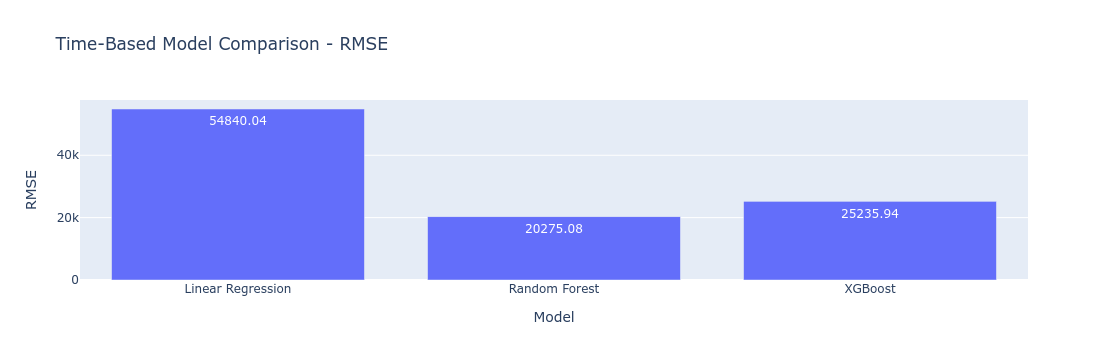

In [23]:
import plotly.express as px

fig = px.bar(
    time_results,
    x="Model",
    y="RMSE",
    title="Time-Based Model Comparison - RMSE",
    text_auto=".2f"
)

fig.show()

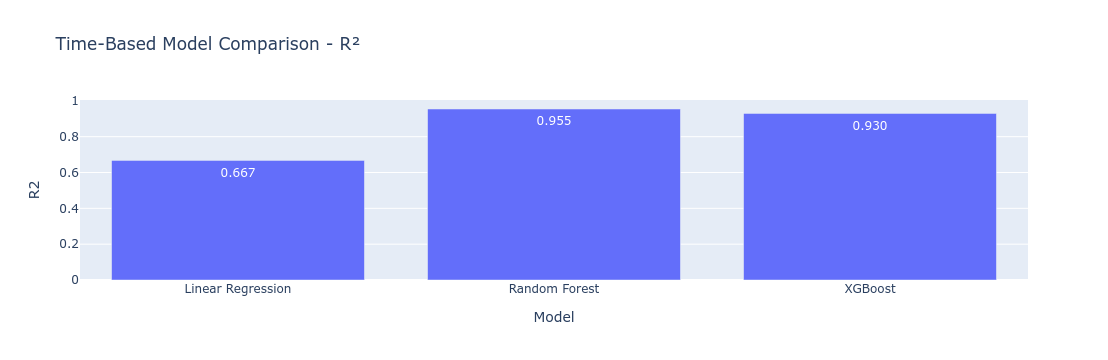

In [24]:
fig = px.bar(
    time_results,
    x="Model",
    y="R2",
    title="Time-Based Model Comparison - R²",
    text_auto=".3f"
)

fig.show()

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Create improved Random Forest
rf_tuned = Pipeline([
    ("preprocessor", preprocessor_time),

    ("model", RandomForestRegressor(
        n_estimators=400,
        max_depth=20,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

# Train
rf_tuned.fit(
    X_train_time,
    y_train_time
)

# Predict
rf_tuned_pred = rf_tuned.predict(
    X_test_time
)

# Metrics
rf_tuned_mae = mean_absolute_error(
    y_test_time,
    rf_tuned_pred
)

rf_tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test_time,
        rf_tuned_pred
    )
)

rf_tuned_r2 = r2_score(
    y_test_time,
    rf_tuned_pred
)

print("TUNED RANDOM FOREST")
print("===================")
print("MAE :", rf_tuned_mae)
print("RMSE:", rf_tuned_rmse)
print("R²  :", rf_tuned_r2)

TUNED RANDOM FOREST
MAE : 16852.46300621669
RMSE: 29673.437443197057
R²  : 0.902646735321814


In [26]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Tuned Random Forest"
    ],

    "MAE": [
        rf_time_mae,
        rf_tuned_mae
    ],

    "RMSE": [
        rf_time_rmse,
        rf_tuned_rmse
    ],

    "R2": [
        rf_time_r2,
        rf_tuned_r2
    ]
})

print(comparison)

                 Model           MAE          RMSE        R2
0        Random Forest  10356.194638  20275.079135  0.954549
1  Tuned Random Forest  16852.463006  29673.437443  0.902647


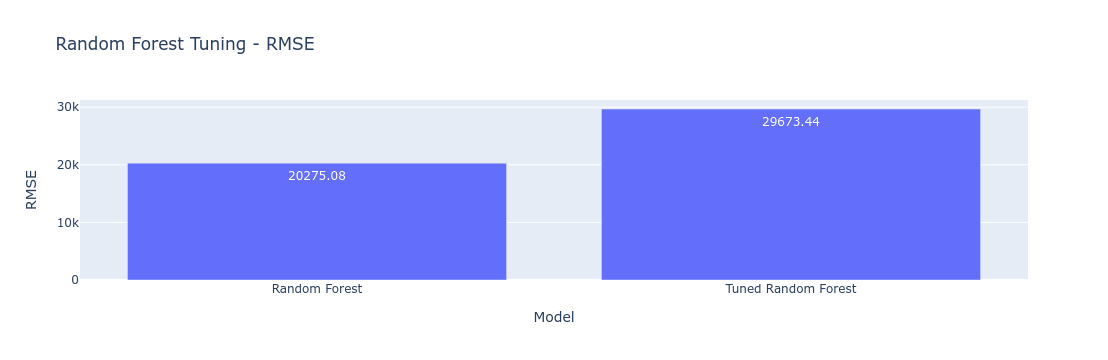

In [27]:
fig = px.bar(
    comparison,
    x="Model",
    y="RMSE",
    title="Random Forest Tuning - RMSE",
    text_auto=".2f"
)

fig.show()

In [28]:
import joblib
import os

# Create models folder
os.makedirs("//home/sushil-singh/50_Projects/yeildsense_V1/models", exist_ok=True)

# Save the original Random Forest pipeline
joblib.dump(
    rf_time,
    "/home/sushil-singh/50_Projects/yeildsense_V1/models/yieldsense_random_forest.pkl"
)

print("Model saved successfully.")

Model saved successfully.
